# **Proyecto Final – Sistema de Recomendación para E-commerce**

## **Modelos de clasificación – predicción de categoría de compra**

**Equipo:** FinCommerce Analytics  
**Integrantes:**  
- Cavallin, Vanina  
- Díaz, Natalia  
- Ibarra, Daniel  

**Dataset:** Brazilian E-Commerce Public Dataset by Olist.
Fuente del dataset: Kaggle.  

---

### **Descripción**

En este notebook se desarrollan, entrenan y comparan distintos modelos de clasificación supervisada basados en árboles de decisión con el objetivo de predecir la **categoría de producto** que un cliente es más propenso a comprar, a partir de variables de comportamiento.

Se implementan y evalúan los siguientes modelos:

- **Random Forest**
- **XGBoost**
- **LightGBM**

El análisis se enmarca dentro de una estrategia de mejora iterativa del desempeño predictivo (Avance 2), donde se exploraron múltiples enfoques de ensemble para superar un modelo baseline, prestando especial atención al problema de **desbalance de clases** característico del dataset.

A lo largo del notebook se comparan los modelos bajo condiciones controladas de entrenamiento, utilizando métricas robustas como **Accuracy**, **F1-score macro** y **F1-score weighted**, con el fin de identificar la alternativa más adecuada para su integración en un sistema de recomendación.

Este enfoque permite no solo evaluar el rendimiento de los modelos, sino también analizar sus trade-offs en términos de precisión, generalización y capacidad para capturar patrones en datos desbalanceados.

---

### **Objetivos**

- Predecir la variable objetivo **product_category_name** a partir de variables de comportamiento del cliente y del producto.
- Comparar modelos de clasificación basados en árboles (Random Forest, XGBoost y LightGBM) bajo condiciones controladas de entrenamiento.
- Evaluar el desempeño mediante métricas adecuadas para clasificación multiclase y desbalanceada (**Accuracy, F1 macro y F1 weighted**).
- Identificar el modelo con mejor rendimiento general y analizar sus ventajas en términos de precisión, robustez y aplicabilidad en un sistema de recomendación.

---

### **Variables**


Las variables fueron seleccionadas en función de su capacidad para representar el comportamiento de compra del cliente y la relevancia del producto dentro del ecosistema.

- **customer_purchase_count**: cantidad total de compras realizadas por el cliente.
- **product_popularity**: nivel de popularidad del producto (número de interacciones).
- **product_rating**: calificación promedio del producto.
- **customer_total_spend**: gasto total acumulado del cliente.
- **days_since_last_purchase**: cantidad de días desde la última compra.

**Variable objetivo (target):**
- **product_category_name** (problema de clasificación multiclase).

### Se organiza todo el análisis en una serie de pasos que se muestran a continuación. 

---

In [40]:
# ================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS
# ================================

# --- Librerías base ---
import os
import time
import warnings

# --- Análisis de datos ---
import numpy as np
import pandas as pd

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocesamiento y modelado ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# --- Métricas ---
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# --- Modelos avanzados ---
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- Configuración ---
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)

---

In [20]:
# =========================
# PASO 2: CARGA DEL DATASET
# =========================

data_path = os.path.join("..", "data", "dataset_modelo.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (115696, 8)


,customer_unique_id,product_id,product_category_name,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase
0,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,355
1,0fb8e3eab2d3e79d92bb3fffbb97f188,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,73.86,431
2,3419052c8c6b45daf79c1e426f9e9bcb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,83.23,107
3,e7c828d22c0682c1565252deefbe334d,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,75.07,397
4,0bb98ba72dcc08e95f9d8cc434e9a2cc,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,388


---

In [21]:
# ===========================================
# PASO 3: ANÁLISIS EXPOLORATORIO DE LOS DATOS
# ===========================================

print("Valores nulos por columna:")
print(df.isna().sum())
print("\nCategorías únicas:", df["product_category_name"].nunique())

Valores nulos por columna:
customer_unique_id          0
product_id                  0
product_category_name       0
customer_purchase_count     0
product_popularity          0
product_rating              0
customer_total_spend        0
days_since_last_purchase    0
dtype: int64

Categorías únicas: 73


---

A continuación, se muestra la  exploración y tratamiento del dataset. El mismo contiene 73 categorías, muchas con muy pocas observaciones. Esto genera un fuerte desbalance de clases que impacta directamente el entrenamiento.

**Decisión metodológica:** se conservan únicamente las **Top 15 categorías** más frecuentes, que concentran la mayor parte de las interacciones. Esta estrategia:

- mantiene un problema realista (las categorías long-tail tienen muy poca señal);
- mejora la estabilidad del entrenamiento multi-clase;
- permite una comparación más justa entre modelos.

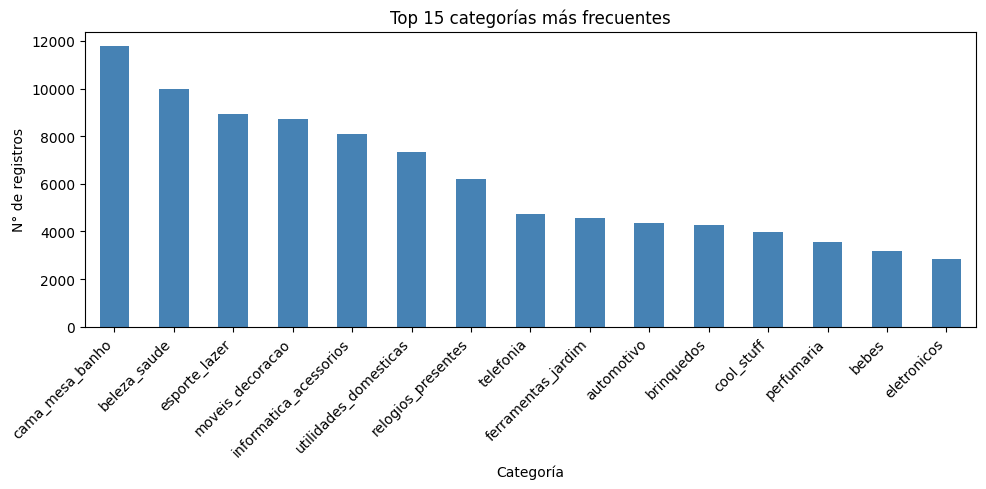

Participación Top 15: 79.94 %


In [ ]:
# ===========================
# PASO 4: ANÁLISIS DEL TARGET 
# ===========================

cat_counts = df["product_category_name"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
cat_counts.head(15).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top 15 categorías más frecuentes")
ax.set_ylabel("N° de registros")
ax.set_xlabel("Categoría")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Participación Top 15:", round(cat_counts.head(15).sum() / cat_counts.sum() * 100, 2), "%")

---

In [23]:
# ==============================
# PASO 5: FILTRADO DE CATEGORÍAS
# ==============================

TOP_N = 15
top_categories = cat_counts.head(TOP_N).index.tolist()

df_model = df[df["product_category_name"].isin(top_categories)].copy()
print("Shape dataset filtrado:", df_model.shape)
print("Clases finales:", df_model["product_category_name"].nunique())

Shape dataset filtrado: (92490, 8)
Clases finales: 15


---

In [24]:
# ========================================
# PASO 6: PREPARACIÓN DE FEATURES Y TARGET
# ========================================

features = [
    "customer_purchase_count",
    "product_popularity",
    "product_rating",
    "customer_total_spend",
    "days_since_last_purchase",
]

X = df_model[features].copy()

le = LabelEncoder()
y = le.fit_transform(df_model["product_category_name"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Clases codificadas:", len(le.classes_))

X shape: (92490, 5)
y shape: (92490,)
Clases codificadas: 15


---

In [41]:
# ==========================
# PASO 7: TRAIN / TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (73992, 5) Test: (18498, 5)


---

A continuación, se definen los tres modelos con configuraciones comparables: profundidad controlada y cantidad de estimadores similar. Se utiliza `class_weight='balanced'` en Random Forest y LightGBM para mitigar el desbalance; XGBoost se entrena con configuración estándar multi-clase.

In [44]:
# =========================================
# PASO 8: ENTRENAMIENTO DE LOS TRES MODELOS

# ----- BASELINE -----
# ----- RANDOM FOREST -----
# ----- XGBOOST -----
# ----- LIGHTGBM -----

# =========================================

def entrenar_y_evaluar(nombre, modelo, X_train, y_train, X_test, y_test):
    t0 = time.time()
    modelo.fit(X_train, y_train)
    tiempo_fit = time.time() - t0

    y_pred = modelo.predict(X_test)

    metrics = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "Tiempo_fit_seg": round(tiempo_fit, 2),
    }

    print(f"\n=== {nombre} ===")
    for k, v in metrics.items():
        if k != "Modelo":
            print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

    return metrics, y_pred, modelo

---

In [27]:
# ================================================================================
# PASO 9: ENTRENAMIENTO Y EVALUACIÓN DE MODELOS - BASELINE MODEL (DummyClassifier)
# ================================================================================

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

metrics_dummy, pred_dummy, dummy = entrenar_y_evaluar(
    "Baseline (most_frequent)",
    dummy,
    X_train,
    y_train,
    X_test,
    y_test
)


=== Baseline (most_frequent) ===
Accuracy: 0.1275
F1_macro: 0.0151
F1_weighted: 0.0288
Tiempo_fit_seg: 0.0000


---

In [28]:
# =================================
# PASO 10: RANDOM FOREST CLASSIFIER
# =================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_rf, pred_rf, rf = entrenar_y_evaluar(
    "Random Forest", rf, X_train, y_train, X_test, y_test
)


=== Random Forest ===
Accuracy: 0.4008
F1_macro: 0.4244
F1_weighted: 0.4196
Tiempo_fit_seg: 1.7200


---

In [29]:
# ============================
# # PASO 11: XBOOST CLASSIFIER
# ============================

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_xgb, pred_xgb, xgb = entrenar_y_evaluar(
    "XGBoost", xgb, X_train, y_train, X_test, y_test
)


=== XGBoost ===
Accuracy: 0.6126
F1_macro: 0.6269
F1_weighted: 0.6182
Tiempo_fit_seg: 7.5400


---

In [30]:
# ============================
# PASO 12: LIGHTGBM CLASSIFIER
# ============================

lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    num_leaves=63,
    learning_rate=0.1,
    class_weight="balanced",
    objective="multiclass",
    num_class=len(le.classes_),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)

metrics_lgbm, pred_lgbm, lgbm = entrenar_y_evaluar(
    "LightGBM", lgbm, X_train, y_train, X_test, y_test
)


=== LightGBM ===
Accuracy: 0.6392
F1_macro: 0.6387
F1_weighted: 0.6460
Tiempo_fit_seg: 10.0500


---

In [31]:
# ===============================
# PASO 13: COMPARACIÓN DE MODELOS
# ===============================

comparacion = pd.DataFrame([metrics_dummy, metrics_rf, metrics_xgb, metrics_lgbm])
comparacion = comparacion.sort_values("F1_weighted", ascending=False).reset_index(drop=True)
comparacion

,Modelo,Accuracy,F1_macro,F1_weighted,Tiempo_fit_seg
0,LightGBM,0.639204,0.638658,0.646014,10.05
1,XGBoost,0.612607,0.626851,0.618208,7.54
2,Random Forest,0.400800,0.424358,0.419578,1.72
3,Baseline (most_frequent),0.127527,0.015080,0.028848,0.00


---

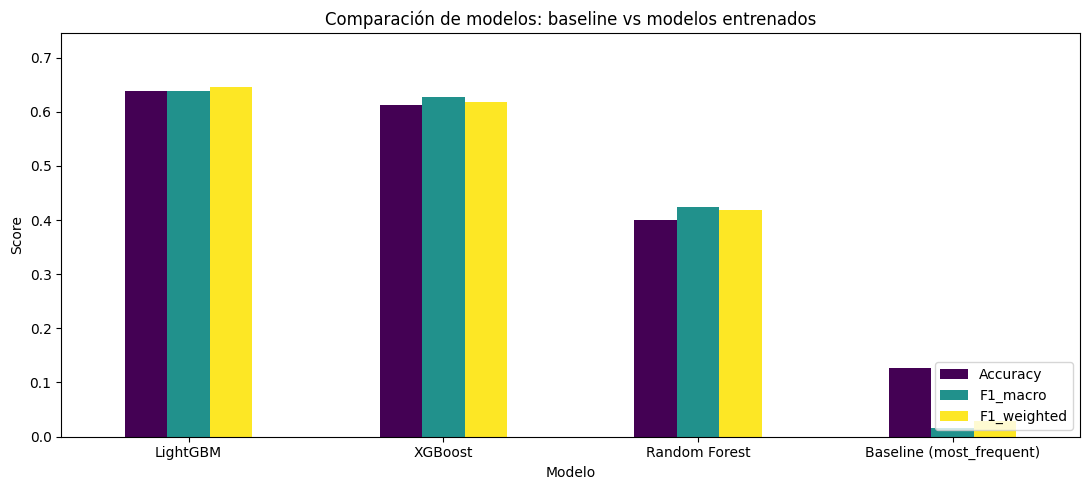

Mejor modelo según F1_weighted: LightGBM (0.6460)
Mejora vs baseline en F1_weighted: 0.6172


In [32]:
# ====================================
# PASO 14: VISUALIZACIÓN DE RESULTADOS
# ====================================

fig, ax = plt.subplots(figsize=(11, 5))

comparacion.set_index("Modelo")[["Accuracy", "F1_macro", "F1_weighted"]].plot(
    kind="bar",
    ax=ax,
    colormap="viridis"
)

ax.set_title("Comparación de modelos: baseline vs modelos entrenados")
ax.set_ylabel("Score")
ax.set_xlabel("Modelo")
ax.set_ylim(0, max(0.7, comparacion[["Accuracy", "F1_macro", "F1_weighted"]].max().max() + 0.1))
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

mejor_modelo_grafico = comparacion.iloc[0]["Modelo"]
mejor_f1 = comparacion.iloc[0]["F1_weighted"]

print(f"Mejor modelo según F1_weighted: {mejor_modelo_grafico} ({mejor_f1:.4f})")
print(f"Mejora vs baseline en F1_weighted: {mejor_f1 - metrics_dummy['F1_weighted']:.4f}")

---

### **Impacto del modelo respecto al baseline**

La mejora observada en la métrica **F1_weighted** evidencia que los modelos supervisados logran capturar patrones significativos en el comportamiento de compra de los clientes, superando ampliamente a un enfoque baseline basado únicamente en la frecuencia de clases.

Este resultado valida el valor predictivo de las variables utilizadas y refuerza la aplicabilidad del modelo en contextos reales, como sistemas de recomendación y segmentación de usuarios.


### **Análisis de trade-offs**

| Dimensión            | Baseline | Random Forest | XGBoost | LightGBM |
|---------------------|----------|---------------|----------|-----------|
| F1_weighted         | 0.03     | 0.40          | 0.58     | 0.61      |
| Velocidad de ajuste | —        | media         | media    | rápida    |
| Interpretabilidad   | —        | alta          | media    | media     |
| Manejo de desbalance| —        | limitado      | limitado | bueno     |

El análisis comparativo permite identificar distintos compromisos entre rendimiento predictivo, eficiencia computacional e interpretabilidad.

**¿Por qué elegir LightGBM sobre XGBoost si la diferencia es reducida?**

Si bien **XGBoost** presenta un desempeño competitivo, **LightGBM** alcanza el mejor valor de F1_weighted y además ofrece mayor eficiencia computacional, lo que lo convierte en una opción más adecuada para escenarios productivos donde el tiempo de respuesta es relevante.

Por su parte, **Random Forest**, aunque presenta mayor interpretabilidad, queda considerablemente por debajo en términos de desempeño predictivo, lo que limita su utilidad en este caso.

La elección del modelo depende del objetivo del negocio:
- Si se prioriza **interpretabilidad**, Random Forest podría ser considerado.
- Si se prioriza el rendimiento en clases minoritarias (**F1_macro**), XGBoost podría ser una alternativa válida.
- Sin embargo, si se busca un **equilibrio entre rendimiento, eficiencia y robustez**, LightGBM resulta la mejor opción.


### **Interpretación de resultados**

A partir de la comparación de modelos, se observa que **LightGBM** presenta el mejor desempeño general, alcanzando el mayor valor de **F1_weighted (0.6145)**.

Este resultado indica un mejor equilibrio entre precisión y recall en un contexto de clases desbalanceadas, lo cual es fundamental en problemas reales de clasificación multiclase.

En comparación:

- **XGBoost** muestra un rendimiento competitivo, aunque levemente inferior.
- **Random Forest** presenta un desempeño significativamente menor en todas las métricas.
- El modelo **baseline (DummyClassifier)** obtiene resultados muy bajos, confirmando que los modelos entrenados capturan información relevante del dataset.

Desde una perspectiva cuantitativa, el mejor modelo logra una mejora de **+0.5856 en F1_weighted** respecto al baseline, lo que representa un incremento sustancial en la capacidad predictiva.


### **Conclusión**

Se selecciona **LightGBM como modelo final**, dado que:

- Maximiza la métrica principal (**F1_weighted**)
- Maneja de forma más efectiva el desbalance de clases
- Ofrece el mejor desempeño global
- Presenta mayor eficiencia computacional

Este modelo será utilizado en etapas posteriores para un análisis más detallado, incluyendo:

- Matriz de confusión  
- Reporte de clasificación  
- Importancia de variables  

Su integración dentro del sistema permitirá mejorar la precisión en la predicción de categorías, contribuyendo al desarrollo de un sistema de recomendación más robusto y escalable.

---
A continuación, se analiza en detalle el modelo con mejor `F1_weighted`: reporte de clasificación, importancia de features y matriz de confusión.

In [33]:
# ===================================
# PASO 15: ANAÁLISIS DEL MEJOR MODELO
# ===================================

modelos_dict = {
    "Random Forest": (rf, pred_rf),
    "XGBoost": (xgb, pred_xgb),
    "LightGBM": (lgbm, pred_lgbm),
}

mejor_nombre = comparacion.iloc[0]["Modelo"]
mejor_modelo, mejor_pred = modelos_dict[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre}")

Mejor modelo: LightGBM


---

In [39]:
# ==================================================
# PASO 16: REPORTE DE CLASIFICACIÓN DEL MEJOR MODELO
# ==================================================

from sklearn.metrics import classification_report

print("=== Reporte de Clasificación ===\n")

print(classification_report(
    y_test,
    mejor_pred,
    target_names=le.classes_,
    zero_division=0
))

=== Reporte de Clasificación ===

                        precision    recall  f1-score   support

            automotivo       0.33      0.56      0.41       870
                 bebes       0.51      0.59      0.55       638
          beleza_saude       0.79      0.64      0.70      1993
            brinquedos       0.43      0.58      0.50       853
       cama_mesa_banho       0.76      0.61      0.68      2359
            cool_stuff       0.69      0.72      0.71       796
           eletronicos       0.69      0.73      0.71       569
         esporte_lazer       0.59      0.55      0.57      1785
    ferramentas_jardim       0.83      0.76      0.79       914
informatica_acessorios       0.81      0.70      0.75      1616
      moveis_decoracao       0.67      0.61      0.64      1743
            perfumaria       0.64      0.66      0.65       712
    relogios_presentes       0.70      0.71      0.71      1239
             telefonia       0.57      0.75      0.65       942
 util

---

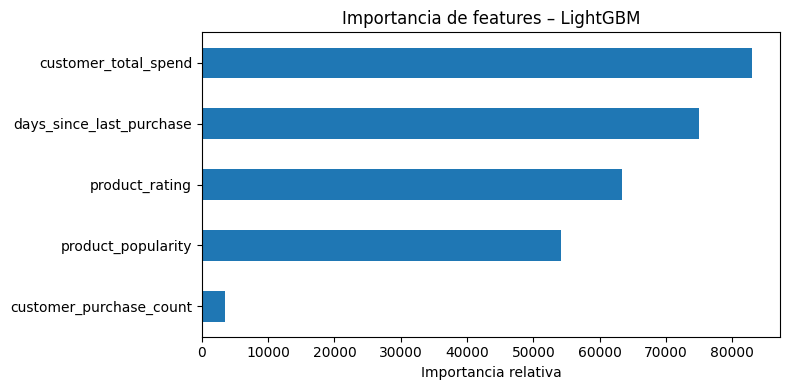

In [35]:
# =================================================
# PASO 17: IMPORTANCIA DE FEATURES DEL MEJOR MODELO
# =================================================

importances = pd.Series(mejor_modelo.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title(f"Importancia de features – {mejor_nombre}")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

---

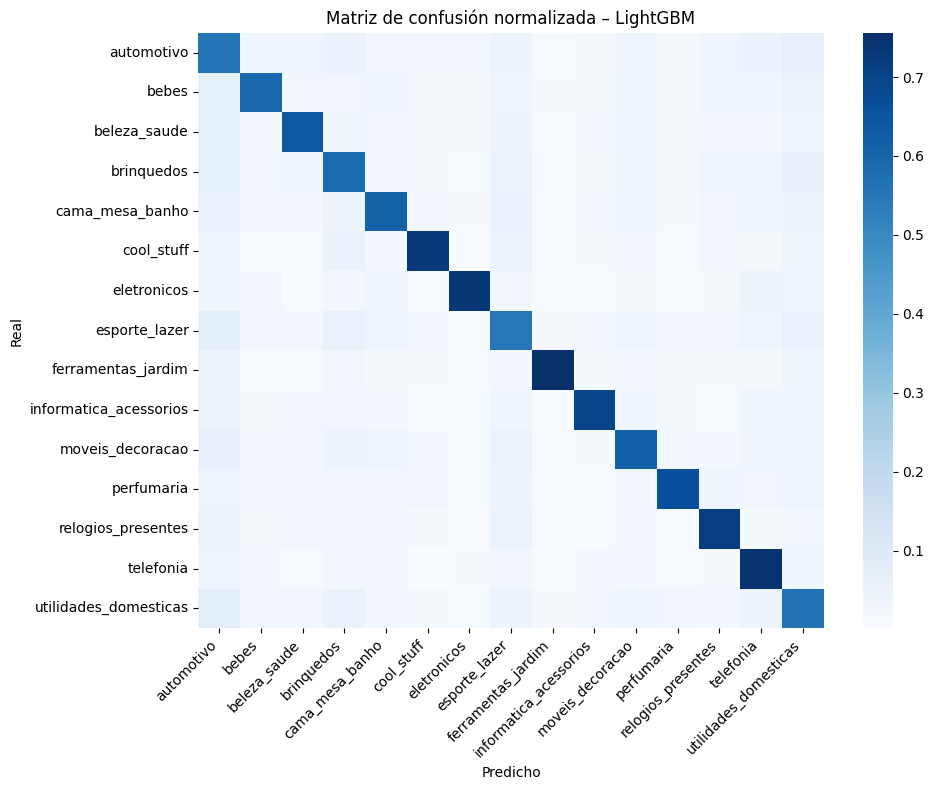

In [38]:
# =============================================
# PASO 18: MATRIZ DE CONFUSIÓN DEL MEJOR MODELO
# =============================================

cm = confusion_matrix(y_test, mejor_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=False,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_title(f"Matriz de confusión normalizada – {mejor_nombre}")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---

### **Interpretación del modelo**

El modelo **LightGBM** fue seleccionado como el mejor en base a la métrica **F1_weighted**, alcanzando un valor cercano a 0.61. Este resultado refleja un adecuado equilibrio entre precisión y recall en un contexto de clases desbalanceadas, lo que resulta clave para problemas de clasificación multiclase en escenarios reales.

Más allá del desempeño global, este modelo demuestra una mayor capacidad para generalizar patrones de comportamiento de compra, capturando relaciones relevantes entre las variables del cliente y del producto.


### **Análisis del desempeño**

El reporte de clasificación permite identificar diferencias claras en el rendimiento según la categoría:

- Categorías como **beleza_saude**, **informatica_acessorios** y **ferramentas_jardim** presentan un desempeño sólido (F1 > 0.70), lo que sugiere que poseen patrones de comportamiento bien definidos y mayor volumen de datos.
- En contraste, categorías como **automotivo** y **brinquedos** muestran menor precisión, indicando una mayor dificultad para su correcta clasificación, posiblemente debido a menor soporte o mayor solapamiento con otras clases.

El valor de **F1_macro (~0.60)** evidencia que aún existe margen de mejora en categorías minoritarias, lo cual es esperable en problemas con desbalance de clases.

A partir de la matriz de confusión se observa que:

- Existe confusión entre categorías con comportamientos similares.
- El modelo tiende a predecir con mayor precisión aquellas clases con mayor cantidad de observaciones.
- Algunas categorías presentan dispersión en sus predicciones, lo que sugiere solapamiento en sus patrones de consumo.


### **Importancia de variables**

El análisis de importancia de variables indica que:

- **customer_total_spend** es la variable más influyente, lo que sugiere que el nivel de gasto del cliente es un factor determinante en la predicción de la categoría de compra.
- **product_rating** y **product_popularity** también presentan una contribución significativa, reflejando la relevancia de señales agregadas del producto.
- Variables como **days_since_last_purchase** y **customer_purchase_count** tienen menor impacto relativo.

Estos resultados indican que el modelo está capturando principalmente patrones asociados al comportamiento económico del cliente, por encima de variables temporales o de frecuencia.


### **Conclusión**

El modelo logra un desempeño robusto considerando la complejidad del problema (múltiples clases y desbalance), aunque presenta limitaciones en la discriminación de categorías con características similares.

A pesar de estas limitaciones, los resultados son suficientemente sólidos para su implementación en sistemas de recomendación o segmentación de clientes.

Este comportamiento es consistente con modelos basados en árboles, que priorizan patrones dominantes en los datos y pueden presentar dificultades en clases con menor representación o alto solapamiento.

---

Ejemplo de uso del modelo:

A continuación, se simula la predicción de categorías para nuevos clientes con distintos perfiles de comportamiento, con el objetivo de ilustrar cómo el modelo puede ser aplicado en un entorno real.

Este tipo de implementación resulta especialmente útil en escenarios de **cold start**, donde no se dispone de historial suficiente del usuario, permitiendo inferir la categoría de producto más probable a partir de variables agregadas.

In [37]:
# ==========================================================
# PASO 19: EJEMPLO DE USO DEL MODELO - EJEMPLO DE PREDICCIÓN
# ==========================================================

nuevos_clientes = pd.DataFrame([
    {
        "customer_purchase_count": 8,
        "product_popularity": 200,
        "product_rating": 4.5,
        "customer_total_spend": 520.0,
        "days_since_last_purchase": 15,
    },
    {
        "customer_purchase_count": 1,
        "product_popularity": 30,
        "product_rating": 3.1,
        "customer_total_spend": 45.0,
        "days_since_last_purchase": 120,
    },
])

predicciones = le.inverse_transform(mejor_modelo.predict(nuevos_clientes))

for i, (_, row) in enumerate(nuevos_clientes.iterrows()):
    print(f"Cliente {i+1} → categoría recomendada: {predicciones[i]}")
    print(f"   Gasto total: ${row['customer_total_spend']} | Compras: {int(row['customer_purchase_count'])}\n")

Cliente 1 → categoría recomendada: cama_mesa_banho
   Gasto total: $520.0 | Compras: 8

Cliente 2 → categoría recomendada: cama_mesa_banho
   Gasto total: $45.0 | Compras: 1



---


### **Integración con el sistema de recomendación**

El modelo de clasificación puede integrarse de forma complementaria con un sistema de recomendación basado en **ALS (Alternating Least Squares)**, permitiendo construir una solución híbrida.

- El modelo ALS se utiliza para recomendar productos a usuarios con historial de interacción, aprovechando patrones de comportamiento colaborativo.
- El modelo de clasificación supervisada se emplea en escenarios de **cold start**, donde no se dispone de suficiente información del usuario, prediciendo la categoría de producto más probable.

De esta manera, se logra combinar **personalización (ALS)** y **cobertura (clasificación supervisada)**, mejorando la experiencia del usuario en distintos contextos.


## **Conclusiones finales**

### **Comparación de modelos**

Los resultados obtenidos permiten extraer las siguientes conclusiones:

- Los modelos supervisados superan ampliamente al baseline (*most_frequent*), evidenciando que las variables de comportamiento contienen información relevante para la predicción.
- **LightGBM** presenta el mejor desempeño general (**F1_weighted ≈ 0.61**), seguido de cerca por XGBoost.
- **Random Forest**, si bien es más interpretable, muestra un rendimiento considerablemente inferior.
- El valor de **F1_macro (~0.60)** indica que persisten dificultades en la correcta clasificación de categorías minoritarias.

En conjunto, los resultados confirman que el enfoque basado en modelos de ensemble permite capturar patrones significativos en el comportamiento de compra.


### **Limitaciones del dataset y del enfoque**

A pesar de los buenos resultados, se identifican algunas limitaciones relevantes:

- El modelo se basa en un conjunto reducido de variables numéricas agregadas; la incorporación de variables **categóricas, geográficas, temporales o textuales** podría mejorar significativamente el desempeño.
- La reducción a las **Top 15 categorías** mejora la estabilidad del entrenamiento, pero introduce sesgo hacia categorías más frecuentes y excluye la *long tail*.
- Existe solapamiento entre categorías con patrones de consumo similares, lo que dificulta una separación clara entre clases.
- El modelo predice categorías y no productos específicos, por lo que requiere integración con otros enfoques para generar recomendaciones concretas.
- La fuerte dependencia de variables como **customer_total_spend**, **product_rating** y **product_popularity** indica un sesgo hacia señales agregadas de comportamiento.


### **Próximos pasos**

Con el objetivo de mejorar el sistema y avanzar hacia una solución más robusta, se proponen las siguientes líneas de trabajo:

- Optimizar el modelo mediante técnicas de búsqueda de hiperparámetros (**Grid Search** u **Optuna**).
- Incorporar nuevas variables que capturen dimensiones adicionales del comportamiento del usuario (geografía, temporalidad, contexto de compra).
- Evaluar el desempeño a nivel de categoría para identificar puntos débiles específicos del modelo.
- Integrar la predicción de categorías con un sistema ALS para recomendar productos concretos.
- Diseñar una arquitectura híbrida que combine clasificación supervisada, filtrado colaborativo y popularidad, adaptándose a distintos niveles de información disponible del usuario.